# 2. Reading and analysing the public accounts

**Questions.** Where does Italian public money come from and where does it go? How do spending and revenues compare with Germany,
France, Spain and the EU average? How much of the deficit is cyclical and how much structural? Has fiscal policy reacted to the level of
debt? How exposed is the budget to higher interest rates?

**Concepts** (a longer guide is in [`docs/reading_public_accounts.md`](../../docs/reading_public_accounts.md)):

- The **State budget** (*bilancio dello Stato*, MEF-RGS, approved by Parliament with the *legge di bilancio*) covers only the central
  State, on a legal-commitment and cash basis. The EU rules use the **general government** account (S13: State, local authorities,
  social security funds), compiled by ISTAT under the ESA 2010 accrual standard; the Maastricht **debt** is compiled by the Bank of Italy.
- **Net lending/borrowing** (B9) is the deficit; the **primary balance** excludes interest; the **structural balance** removes the effect
  of the business cycle and one-off measures.
- Expenditure is classified by **economic nature** (ESA 2010 items, table `gov_10a_main`) and by **function** (COFOG, `gov_10a_exp`).

**Data.** Eurostat `gov_10a_main`, `gov_10a_exp`, `gov_10dd_edpt1`, `nama_10_gdp`, `irt_lt_mcby_a`; all ratios in % of GDP.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "scripts" / "public_debt").is_dir())
try:
    import public_debt
except ImportError:  # not installed: use the source folder (the extension must be built in place)
    sys.path.insert(0, str(ROOT / "scripts" / "public_debt"))
    import public_debt
from public_debt import accounting, data, dsa, fiscal, growth, synthetic
from public_debt.var import fit_var1

core = public_debt.require_cpp()

DATA_MODE = os.environ.get("PUBLIC_DEBT_DATA_MODE", "official")   # "official" (Eurostat, IMF) or "synthetic" (offline)
OFFICIAL = DATA_MODE == "official"
OUTPUT_DIR = ROOT / "outputs" / "public_accounts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
from public_debt.figstyle import MUTED, NEGATIVE, SERIES, notebook_style, ordinal_colors
notebook_style()   # validated palette, recessive grid, constrained layout (see figstyle.py)
print(f"public_debt {public_debt.__version__} | data mode: {DATA_MODE}")
if not OFFICIAL:
    print("WARNING: synthetic data. Tables and charts are placeholders, not statistics about Italy.")

public_debt 0.1.0 | data mode: official


## 2.1 Revenue and expenditure since 1995

Sources: Eurostat gov_10a_main | Eurostat gov_10a_exp


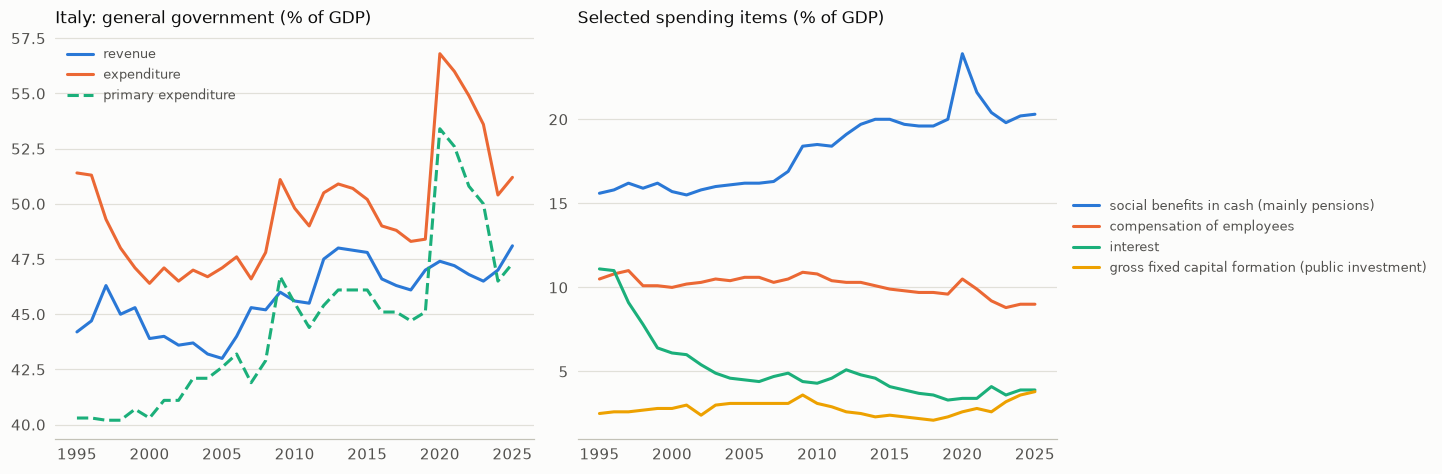

In [2]:
PEERS = ("IT", "DE", "FR", "ES", "EU27_2020")
if OFFICIAL:
    acc = data.government_accounts(PEERS)
    cof = data.cofog_expenditure(PEERS)
    it = data.fiscal_dataset("IT")
    yields = data.bond_yields(PEERS)
else:
    acc, cof, it, yields = (synthetic.government_accounts(PEERS), synthetic.cofog_expenditure(PEERS),
                            synthetic.fiscal_dataset(), synthetic.bond_yields())
print("Sources:", acc.attrs["source"], "|", cof.attrs["source"])

ITEMS = {"TR": "total revenue", "TE": "total expenditure", "D41PAY": "interest", "D1PAY": "compensation of employees",
         "P2": "intermediate consumption", "D62PAY": "social benefits in cash (mainly pensions)",
         "D632PAY": "social transfers in kind via market producers", "D3PAY": "subsidies",
         "P51G": "gross fixed capital formation (public investment)",
         "D2REC": "taxes on production and imports (VAT, excise...)", "D5REC": "current taxes on income and wealth",
         "D61REC": "net social contributions", "D91REC": "capital taxes"}
wide = acc[acc["item"].isin(ITEMS)].pivot_table(index=["geo", "year"], columns="item", values="value")
itw = wide.loc["IT"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(itw.index, itw["TR"], label="revenue")
axes[0].plot(itw.index, itw["TE"], label="expenditure")
axes[0].plot(itw.index, itw["TE"] - itw["D41PAY"], "--", label="primary expenditure")
axes[0].set(title="Italy: general government (% of GDP)")
axes[0].legend(loc="upper left")
for code_, color in zip(("D62PAY", "D1PAY", "D41PAY", "P51G"), SERIES):
    axes[1].plot(itw.index, itw[code_], color=color, label=ITEMS[code_])
axes[1].set(title="Selected spending items (% of GDP)")
axes[1].legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
fig.savefig(OUTPUT_DIR / "revenue_expenditure.png", dpi=150)

## 2.2 Italy compared with its peers

Latest year available for all countries. Positive gaps mean that Italy spends (or collects) more than the EU average, as a share of GDP.

In [3]:
latest = int(wide.reset_index().groupby("geo")["year"].max().min())
comp = wide.xs(latest, level="year").T.rename(index=ITEMS)
comp["Italy - EU27"] = comp["IT"] - comp["EU27_2020"]
print(f"Year: {latest}")
display(comp[list(PEERS) + ["Italy - EU27"]].round(1))

Year: 2025


geo,IT,DE,FR,ES,EU27_2020,Italy - EU27
item,,,,,,
compensation of employees,9.00,8.60,12.40,10.80,10.30,-1.30
"taxes on production and imports (VAT, excise...)",14.10,10.30,15.70,11.30,12.80,1.30
subsidies,1.50,1.20,1.90,1.20,1.40,0.10
interest,3.90,1.10,2.20,2.40,1.90,2.00
current taxes on income and wealth,15.30,12.80,13.00,13.10,13.30,2.00
net social contributions,13.50,18.40,16.70,13.30,14.30,-0.80
social benefits in cash (mainly pensions),20.30,16.80,19.40,17.00,16.50,3.80
social transfers in kind via market producers,2.30,9.30,6.40,2.60,5.40,-3.10
capital taxes,0.10,0.30,0.70,0.40,0.30,-0.20


## 2.3 Spending by function (COFOG)

COFOG divisions: 01 general public services (including **public debt transactions, 0107**), 02 defence, 03 public order and safety,
04 economic affairs, 05 environmental protection, 06 housing, 07 health, 08 recreation and culture, 09 education, 10 social protection
(including **old age, 1002**, i.e. pensions).

Year: 2024


geo,IT,DE,FR,ES,EU27_2020,Italy - EU27
general public services,7.70,6.40,6.20,5.80,6.10,1.60
public debt transactions (interest),4.00,1.10,2.00,2.50,1.90,2.10
defence,1.30,1.40,1.90,0.90,1.50,-0.20
public order and safety,1.80,1.60,1.80,1.80,1.70,0.10
economic affairs,5.10,5.40,5.70,5.10,5.30,-0.20
environmental protection,0.90,0.60,1.00,1.00,0.80,0.10
housing and community,0.80,0.50,1.40,0.50,0.70,0.10
health,6.60,7.60,8.90,6.50,7.30,-0.70
"recreation, culture, religion",0.90,1.10,1.50,1.20,1.20,-0.30
education,4.00,4.50,5.10,4.10,4.70,-0.70


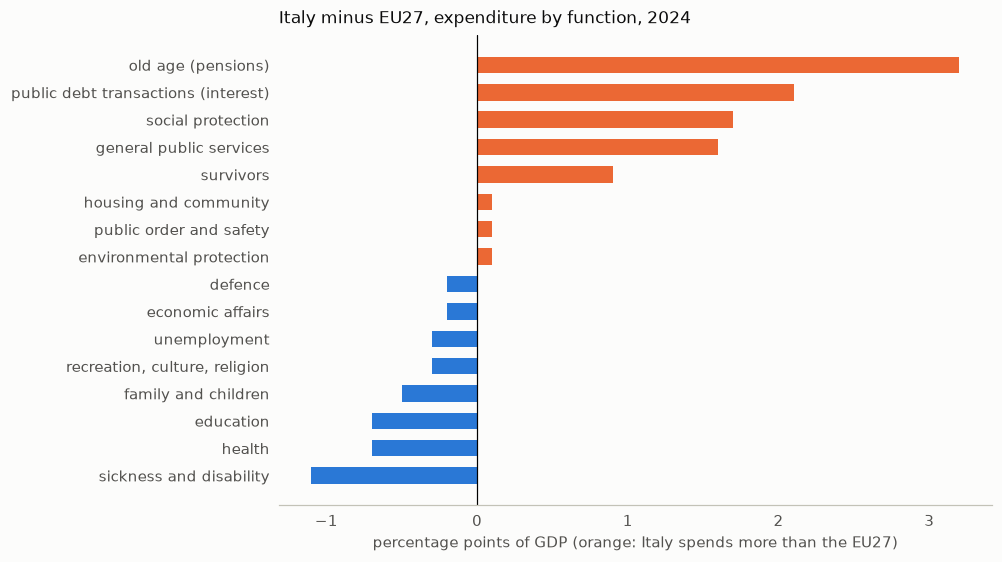

In [4]:
COFOG = {"GF01": "general public services", "GF0107": "public debt transactions (interest)", "GF02": "defence",
         "GF03": "public order and safety", "GF04": "economic affairs", "GF05": "environmental protection",
         "GF06": "housing and community", "GF07": "health", "GF08": "recreation, culture, religion", "GF09": "education",
         "GF10": "social protection", "GF1001": "sickness and disability", "GF1002": "old age (pensions)",
         "GF1003": "survivors", "GF1004": "family and children", "GF1005": "unemployment"}
cw = cof[cof["cofog"].isin(COFOG)].pivot_table(index=["geo", "year"], columns="cofog", values="value")
year_c = int(cof.groupby("geo")["year"].max().min())
fn = cw.xs(year_c, level="year").T
fn.index = [COFOG.get(c, c) for c in fn.index]
fn["Italy - EU27"] = fn["IT"] - fn["EU27_2020"]
fn = fn[[g for g in PEERS if g in fn.columns] + ["Italy - EU27"]]
print(f"Year: {year_c}")
display(fn.round(1))

fig, ax = plt.subplots(figsize=(9, 5))
gap = fn["Italy - EU27"].sort_values()
ax.barh(range(len(gap)), gap.to_numpy(), height=0.6, color=[SERIES[1] if v > 0 else SERIES[0] for v in gap])
ax.set_yticks(range(len(gap)), gap.index)
ax.axvline(0, color="k", lw=0.8)
ax.grid(axis="y", visible=False)
ax.set(xlabel="percentage points of GDP (orange: Italy spends more than the EU27)",
       title=f"Italy minus EU27, expenditure by function, {year_c}")
fig.savefig(OUTPUT_DIR / "cofog_gap.png", dpi=150)

## 2.4 Cyclical adjustment and fiscal stance

The output gap is estimated with a Hodrick-Prescott filter on real GDP ($\lambda = 100$); the cyclically adjusted balance removes
$\varepsilon \times$ gap with $\varepsilon = 0.55$ (close to the European Commission's semi-elasticity for Italy). The change in the
cyclically adjusted primary balance (CAPB) measures the discretionary stance: positive = tightening. A counter-cyclical policy tightens
in good times (positive gap) and loosens in bad times.

Correlation between the output gap and the fiscal stance: 0.27 (positive = counter-cyclical)


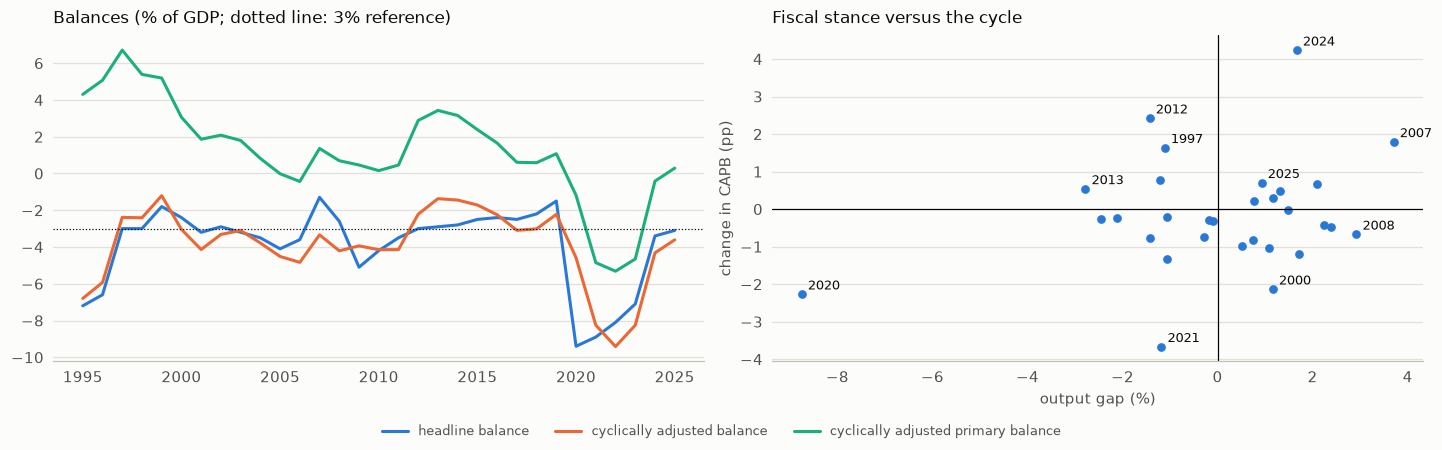

In [5]:
real_gdp = (1 + it["real_growth"].fillna(0)).cumprod()
gap = fiscal.output_gap(real_gdp)
ca = fiscal.cyclically_adjusted(it, gap)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ca.index, 100 * it["balance"], label="headline balance")
axes[0].plot(ca.index, 100 * ca["cyclically adjusted balance"], label="cyclically adjusted balance")
axes[0].plot(ca.index, 100 * ca["cyclically adjusted primary balance"], label="cyclically adjusted primary balance")
axes[0].axhline(-3, color="k", ls=":", lw=0.8)
axes[0].set(title="Balances (% of GDP; dotted line: 3% reference)")
axes[1].scatter(100 * ca["output gap"], 100 * ca["fiscal stance (change in CAPB)"], color=SERIES[0], s=22)
# Label the years that matter for the discussion (large gaps or large changes, and the latest year), not all of them.
points = ca.dropna()
for y, row in points.iterrows():
    gap_, stance_ = 100 * row["output gap"], 100 * row["fiscal stance (change in CAPB)"]
    if abs(gap_) > 2.5 or abs(stance_) > 1.4 or y == points.index.max():
        axes[1].annotate(str(y), (gap_, stance_), xytext=(4, 3), textcoords="offset points", fontsize=8.5)
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center", ncol=3)
axes[1].axhline(0, color="k", lw=0.8); axes[1].axvline(0, color="k", lw=0.8)
axes[1].set(xlabel="output gap (%)", ylabel="change in CAPB (pp)", title="Fiscal stance versus the cycle")
fig.savefig(OUTPUT_DIR / "fiscal_stance.png", dpi=150)
c = ca[["output gap", "fiscal stance (change in CAPB)"]].dropna().corr().iloc[0, 1]
print(f"Correlation between the output gap and the fiscal stance: {c:.2f} (positive = counter-cyclical)")

## 2.5 Has the primary balance reacted to debt? (Bohn test)

$pb_t = a + \rho\, d_{t-1} + \beta\, \text{gap}_t + e_t$. A positive and significant $\rho$ indicates that governments raised the primary
balance when debt was higher, a sufficient condition for sustainability (Bohn, 1998). With about 30 annual observations the estimate is
imprecise; long samples (Mauro et al., 2015) are preferable. Exceptional years can dominate a short sample, so the regression is shown
in four versions: the full sample, with indicator variables for the pandemic (2020-2021) and for the years of the building tax credits
(2022-2023), and on the pre-pandemic sample.

In [6]:
specs = {
    "full sample": {},
    "pandemic dummy 2020-2021": {"dummies": {"pandemic 2020-2021": [2020, 2021]}},
    "pandemic and tax-credit dummies": {"dummies": {"pandemic 2020-2021": [2020, 2021], "tax credits 2022-2023": [2022, 2023]}},
    "pre-pandemic sample": {"years": (int(it.index.min()), 2019)},
}
rows = {}
for name, kw in specs.items():
    r = fiscal.fiscal_reaction(it, gap, **kw)
    rows[name] = {"rho": r.loc["lagged debt ratio (rho)", "coefficient"],
                  "std. error (Newey-West)": r.loc["lagged debt ratio (rho)", "std. error (Newey-West)"],
                  "p-value": r.loc["lagged debt ratio (rho)", "p-value"],
                  "output gap coefficient": r.loc["output gap", "coefficient"], "R^2": r.attrs["r2"],
                  "sample": r.attrs["years"]}
reaction = pd.DataFrame(rows).T
display(reaction)
positive = [k for k, v in rows.items() if v["rho"] > 0 and v["p-value"] < 0.05]
print("Specifications with a positive and significant response of the primary balance to debt:",
      ", ".join(positive) if positive else "none",
      "\nA rho that is zero or negative means that, in this sample, higher debt was not followed by higher primary surpluses:"
      " sustainability then rests on growth and interest rates rather than on a systematic fiscal response." if not positive else "")

,rho,std. error (Newey-West),p-value,output gap coefficient,R^2,sample
full sample,-0.10,0.05,0.04,0.17,0.32,1996-2025
pandemic dummy 2020-2021,-0.06,0.04,0.11,-0.23,0.55,1996-2025
pandemic and tax-credit dummies,-0.01,0.02,0.56,-0.06,0.72,1996-2025
pre-pandemic sample,-0.01,0.03,0.86,-0.08,0.01,1996-2019


Specifications with a positive and significant response of the primary balance to debt: none 
A rho that is zero or negative means that, in this sample, higher debt was not followed by higher primary surpluses: sustainability then rests on growth and interest rates rather than on a systematic fiscal response.


## 2.6 Interest-rate exposure of the budget

A permanent rise of 100 basis points in market rates feeds into the effective rate only as the debt is refinanced. With an average residual
maturity of about seven years, roughly one seventh of the debt is refinanced every year (more in practice, because of short-term bills and
new deficits). The C++ projection shows the extra interest spending year by year.

In [7]:
d0, i0 = float(it["debt"].iloc[-1]), float(it["effective_rate"].iloc[-1])
rate = float(yields["IT"].dropna().iloc[-1]) / 100
years = list(range(int(it.index.max()) + 1, int(it.index.max()) + 11))
base = dsa.Scenario.constant(years[0], 10, growth=0.008, inflation=0.02, market_rate=rate,
                             primary_balance=float(it["primary_balance"].iloc[-1]))
rows = {}
for share in (1 / 10, 1 / 7, 1 / 4):
    b = dsa.project(d0, i0, share, base)
    s = dsa.project(d0, i0, share, base.shifted(market_rate=0.01))
    rows[f"refinanced share {share:.2f}"] = 100 * (s["interest"] - b["interest"])
extra = pd.DataFrame(rows)
display(extra.iloc[[0, 2, 4, 9]].round(2).rename_axis("year").T)
print("Extra interest spending in % of GDP caused by +100 bp on market rates (debt and GDP paths as in the baseline).")

year,2026,2028,2030,2035
refinanced share 0.10,0.13,0.37,0.58,1.04
refinanced share 0.14,0.19,0.51,0.77,1.29
refinanced share 0.25,0.33,0.80,1.12,1.64


Extra interest spending in % of GDP caused by +100 bp on market rates (debt and GDP paths as in the baseline).


## 2.7 A checklist for analysing a budget

1. **Perimeter and basis**: State budget or general government? Cash, legal commitment or accrual (ESA 2010)?
2. **Headline versus primary versus structural balance**: separate interest, the cycle and one-offs (tax amnesties, asset sales).
3. **Composition**: which items drive changes (pensions, public wages, intermediate consumption, investment, interest; direct versus
   indirect taxes and contributions)? Compare with peers as % of GDP and per capita.
4. **Tax expenditures and tax credits**: deductions and credits (such as building bonuses) are spending on the revenue side; check how they
   are recorded (Eurostat decided in 2024 how transferable credits are booked).
5. **Sustainability**: debt-stabilising primary balance, interest-growth differential, maturity and refinancing needs, contingent liabilities
   (state guarantees, pension and health ageing costs).
6. **Rules and plans**: EU framework (net expenditure path of the medium-term fiscal-structural plan, deficit and debt safeguards), national
   balanced-budget rule (Article 81 of the Constitution), assessments of the Ufficio parlamentare di bilancio and the Corte dei conti.
7. **Quality**: does spending support growth (education, R&D, investment execution rates) and equity? Are revenues efficient (tax wedge on
   labour, evasion)?

### References

- Bohn, H. (1998). The behavior of U.S. public debt and deficits. *Quarterly Journal of Economics*, 113(3), 949-963.
- Eurostat (2013). *European System of Accounts ESA 2010*; Eurostat, *Manual on Government Deficit and Debt*.
- Mourre, G., Poissonnier, A. and Lausegger, M. (2019). The semi-elasticities underlying the cyclically-adjusted budget balance: an update and further analysis. European Commission, Discussion Paper 098.
- Mauro, P., Romeu, R., Binder, A. and Zaman, A. (2015). A modern history of fiscal prudence and profligacy. *Journal of Monetary Economics*, 76, 55-70.
- Ufficio parlamentare di bilancio, *Rapporto sulla politica di bilancio* (annual).